In [3]:
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
DATASET_PATH = Path(
    r"C:\Users\HP\Desktop\projects\plantdiseaseprediction\PlantVillage-Dataset\raw\color"
)

print(DATASET_PATH)
print(DATASET_PATH.exists())

C:\Users\HP\Desktop\projects\plantdiseaseprediction\PlantVillage-Dataset\raw\color
True


In [5]:
classes = sorted([
    folder.name
    for folder in DATASET_PATH.iterdir()
    if folder.is_dir()
])

print("Number of classes:", len(classes))

for i, class_name in enumerate(classes, start=1):
    print(f"{i:2d}. {class_name}")

Number of classes: 38
 1. Apple___Apple_scab
 2. Apple___Black_rot
 3. Apple___Cedar_apple_rust
 4. Apple___healthy
 5. Blueberry___healthy
 6. Cherry_(including_sour)___Powdery_mildew
 7. Cherry_(including_sour)___healthy
 8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tomato___S

In [6]:
class_counts = {}

for class_name in classes:
    class_path = DATASET_PATH / class_name
    
    image_files = [
        file for file in class_path.iterdir()
        if file.is_file()
    ]
    
    class_counts[class_name] = len(image_files)

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Images"]
)

class_counts_df

,Class,Images
0,Apple___Apple_scab,630
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Blueberry___healthy,1502
5,Cherry_(including_sour)___Powdery_mildew,1052
6,Cherry_(including_sour)___healthy,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,Corn_(maize)___Common_rust_,1192
9,Corn_(maize)___Northern_Leaf_Blight,985


In [7]:
print("Total images:", class_counts_df["Images"].sum())
print("Number of classes:", len(class_counts_df))

Total images: 54305
Number of classes: 38


In [8]:
class_counts_df.sort_values(
    "Images",
    ascending=False
)

,Class,Images
15,Orange___Haunglongbing_(Citrus_greening),5507
35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
24,Soybean___healthy,5090
16,Peach___Bacterial_spot,2297
28,Tomato___Bacterial_spot,2127
30,Tomato___Late_blight,1909
25,Squash___Powdery_mildew,1835
32,Tomato___Septoria_leaf_spot,1771
33,Tomato___Spider_mites Two-spotted_spider_mite,1676
3,Apple___healthy,1645


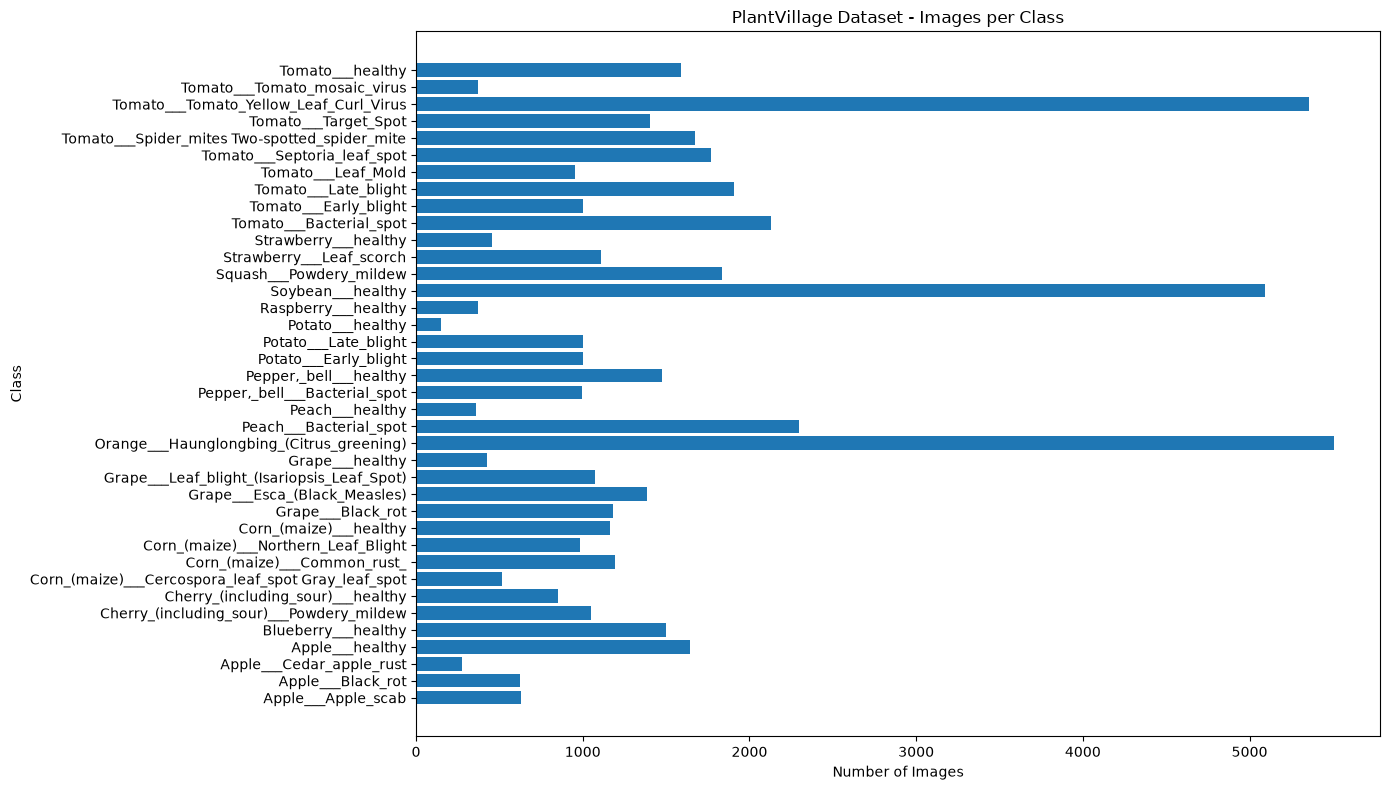

In [9]:
plt.figure(figsize=(14, 8))

plt.barh(
    class_counts_df["Class"],
    class_counts_df["Images"]
)

plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("PlantVillage Dataset - Images per Class")

plt.tight_layout()
plt.show()

In [10]:
sample_class = classes[0]

sample_class_path = DATASET_PATH / sample_class

sample_image_path = next(sample_class_path.iterdir())

print("Class:", sample_class)
print("Image:", sample_image_path)

Class: Apple___Apple_scab
Image: C:\Users\HP\Desktop\projects\plantdiseaseprediction\PlantVillage-Dataset\raw\color\Apple___Apple_scab\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG


In [11]:
image = Image.open(sample_image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (256, 256)
Image mode: RGB


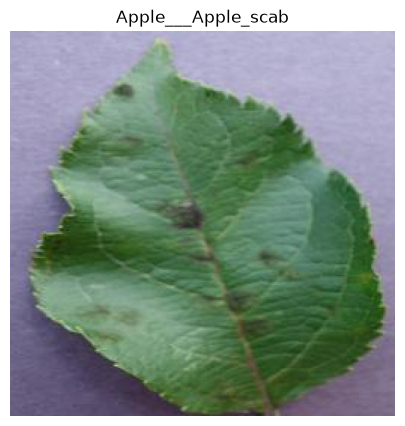

In [12]:
plt.figure(figsize=(5, 5))

plt.imshow(image)
plt.axis("off")
plt.title(sample_class)

plt.show()

In [13]:
corrupted_files = []
dimensions = set()
modes = set()

for class_name in classes:
    class_path = DATASET_PATH / class_name
    for img_path in list(class_path.iterdir())[:50]:
        try:
            with Image.open(img_path) as img:
                img.verify()  
            with Image.open(img_path) as img:
                dimensions.add(img.size)
                modes.add(img.mode)
        except Exception as e:
            corrupted_files.append((img_path, str(e)))

print("Distinct dimensions found:", dimensions)
print("Distinct image modes found:", modes)
print("Total corrupted files detected:", len(corrupted_files))

Distinct dimensions found: {(256, 256)}
Distinct image modes found: {'RGB'}
Total corrupted files detected: 0


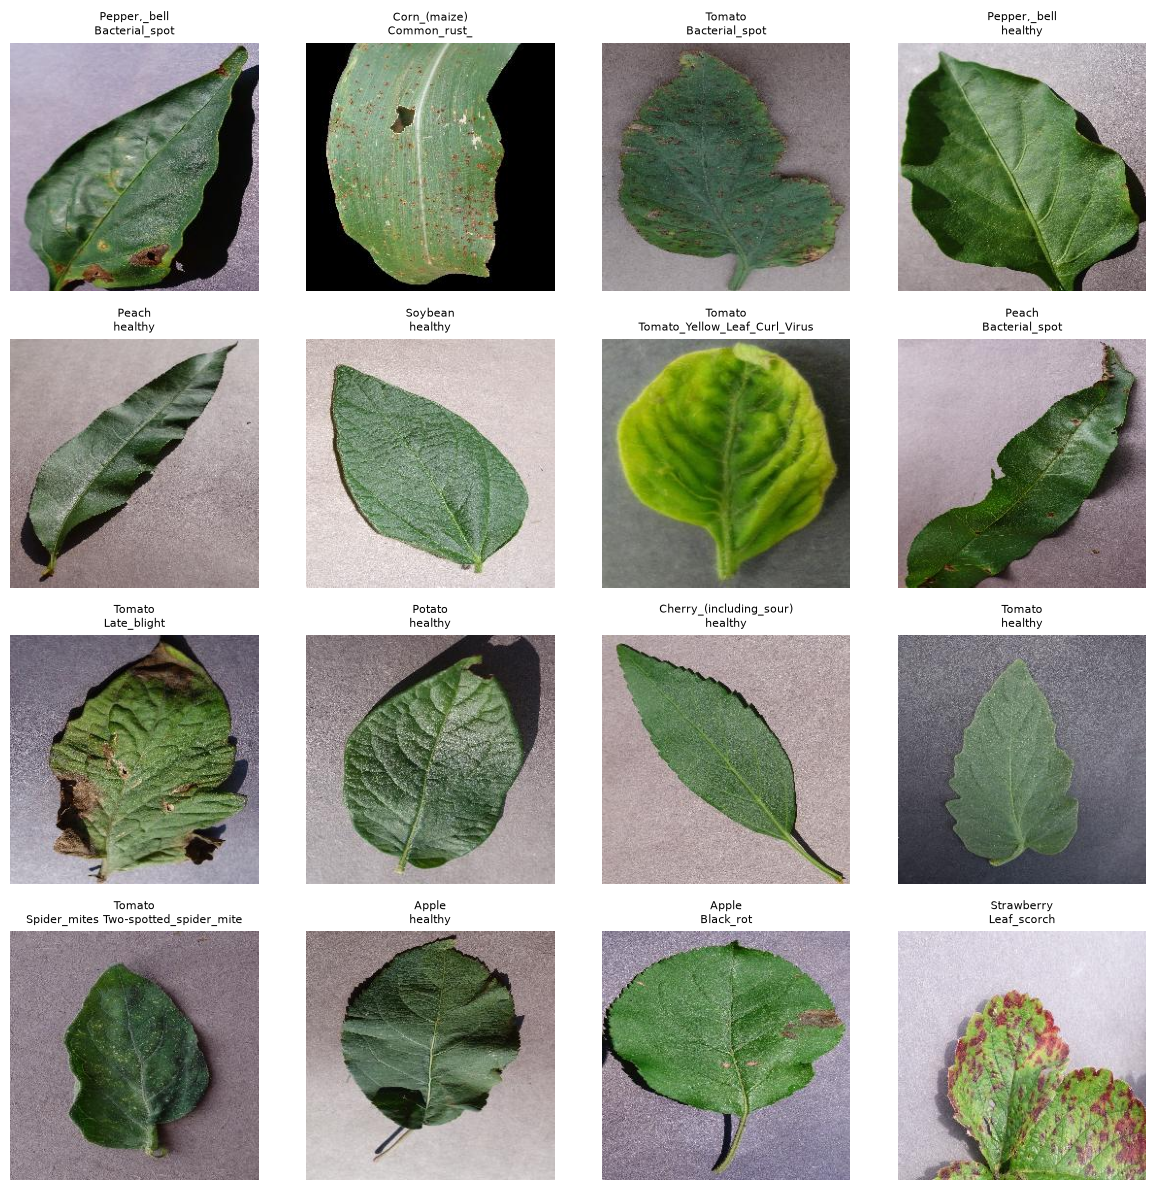

In [14]:
import random

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
selected_classes = random.sample(classes, 16)

for ax, class_name in zip(axes.flatten(), selected_classes):
    class_path = DATASET_PATH / class_name
    sample_file = random.choice(list(class_path.iterdir()))
    img = Image.open(sample_file)
    
    ax.imshow(img)
    ax.set_title(class_name.replace("___", "\n"), fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
data_records = []

for class_name in classes:
    class_path = DATASET_PATH / class_name
    for file_path in class_path.iterdir():
        if file_path.is_file():
            data_records.append({
                "filepath": str(file_path),
                "filename": file_path.name,
                "class_name": class_name
            })

df_dataset = pd.DataFrame(data_records)
print(f"Total entries logged: {len(df_dataset)}")
df_dataset.head()

Total entries logged: 54305


,filepath,filename,class_name
0,C:\Users\HP\Desktop\projects\plantdiseasepredi...,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...,Apple___Apple_scab
1,C:\Users\HP\Desktop\projects\plantdiseasepredi...,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...,Apple___Apple_scab
2,C:\Users\HP\Desktop\projects\plantdiseasepredi...,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...,Apple___Apple_scab
3,C:\Users\HP\Desktop\projects\plantdiseasepredi...,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...,Apple___Apple_scab
4,C:\Users\HP\Desktop\projects\plantdiseasepredi...,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...,Apple___Apple_scab


In [16]:
from sklearn.model_selection import train_test_split

# First split: 70% Train, 30% Temp (Val + Test)
train_df, temp_df = train_test_split(
    df_dataset,
    test_size=0.30,
    random_state=42,
    stratify=df_dataset["class_name"]
)

# Second split: Divide the 30% temp into 15% Val and 15% Test (50/50 split of temp)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_name"]
)

# Tag each subset
train_df = train_df.assign(split="train")
val_df = val_df.assign(split="val")
test_df = test_df.assign(split="test")

full_split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Split summary:")
print(full_split_df["split"].value_counts())

Split summary:
split
train    38013
val       8146
test      8146
Name: count, dtype: int64


In [17]:
potato_check = full_split_df[full_split_df["class_name"] == "Potato___healthy"]
print(potato_check["split"].value_counts())

split
train    106
val       23
test      23
Name: count, dtype: int64


In [18]:
from pathlib import Path

# Target directory: PlantDiseaseProject/data
data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

csv_out_path = data_dir / "dataset_splits.csv"
full_split_df.to_csv(csv_out_path, index=False)

print("Saved split file to:", csv_out_path.resolve())
print("File exists:", csv_out_path.exists())

Saved split file to: C:\Users\HP\Desktop\projects\plantdiseaseprediction\data\dataset_splits.csv
File exists: True
